In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Available training results
results_dir = Path('/home/maurits-heemskerk/Documents/Uni/Master_Thesis/dreamer_results_local')
available_runs = sorted([d for d in results_dir.iterdir() if d.is_dir() and 'dreamer-results' in d.name])

print("Available training runs:")
for i, run in enumerate(available_runs):
    label = run.name.split('dreamer-results-')[1]  # Extract label part
    label = label[13:]  # Remove timestamp (YYYYMMDD-HHMMSS-)
    print(f"  [{i}] {label} ({run.name})")

print(f"\n✓ Loaded {len(available_runs)} available runs")

Available training runs:
  [0] 40-non-informed (dreamer-results-20260309-092340-non-informed)
  [1] 14-imagelossscale100 (dreamer-results-20260321-111314-imagelossscale100)
  [2] 48-256trainratio (dreamer-results-20260323-120848-256trainratio)
  [3] 54-smallrssm128trainratio (dreamer-results-20260323-124454-smallrssm128trainratio)
  [4] 45-largerssm (dreamer-results-20260323-231645-largerssm)
  [5] 46-lossscale10image (dreamer-results-20260323-231846-lossscale10image)
  [6] 37-lossscale3vector (dreamer-results-20260324-222537-lossscale3vector)
  [7] 09-256trainratio-40milsteps (dreamer-results-20260325-010309-256trainratio-40milsteps)

✓ Loaded 8 available runs


In [8]:
import yaml

# Load ALL config files at once
all_configs = {}
for idx, run_path in enumerate(available_runs):
    config_file = run_path / 'config.yaml'
    if config_file.exists():
        with open(config_file, 'r') as f:
            all_configs[idx] = {
                'path': run_path,
                'label': run_path.name.split('dreamer-results-')[1][13:],
                'config': yaml.safe_load(f)
            }

print(f"✓ Loaded {len(all_configs)} config files")

# Helper to extract nested values
def get_nested(d, key):
    """Get value from nested dict using dot notation (e.g., 'run.train_ratio')"""
    keys = key.split('.')
    val = d
    for k in keys:
        if isinstance(val, dict):
            val = val.get(k)
        else:
            return None
    return val

# Find ALL differences across all configs
def find_all_config_differences(configs_dict):
    """Find all parameters that differ across configs"""
    
    def recurse_all(dict_list, current_path=""):
        all_keys = set()
        for d in [c.get('config', {}) for c in dict_list]:
            if isinstance(d, dict):
                all_keys.update(d.keys())
        
        results = {}
        for key in sorted(all_keys):
            new_path = f"{current_path}.{key}" if current_path else key
            
            # Get values for this parameter across all configs
            values = {}
            all_dicts = {}
            for idx, cfg_data in configs_dict.items():
                d = cfg_data.get('config', {})
                v = d.get(key) if isinstance(d, dict) else None
                values[idx] = v
                all_dicts[idx] = d.get(key) if isinstance(d, dict) else None
            
            # Check if all are dicts (recurse)
            if all(isinstance(v, dict) for v in values.values()):
                nested = recurse_all(
                    [{**cfg_data, 'config': values[idx]} for idx, cfg_data in configs_dict.items()],
                    new_path
                )
                results.update(nested)
            else:
                # Check if there are differences
                unique_values = set(str(v) for v in values.values())
                if len(unique_values) > 1:
                    results[new_path] = values
        
        return results
    
    # Start recursion with original configs
    def full_recurse(configs_dict, current_path=""):
        all_keys = set()
        for idx, cfg_data in configs_dict.items():
            d = cfg_data.get('config', {})
            if isinstance(d, dict):
                all_keys.update(d.keys())
        
        results = {}
        for key in sorted(all_keys):
            new_path = f"{current_path}.{key}" if current_path else key
            values = {}
            next_configs = {}
            
            for idx, cfg_data in configs_dict.items():
                d = cfg_data.get('config', {})
                v = d.get(key) if isinstance(d, dict) else None
                values[idx] = v
                if isinstance(v, dict):
                    next_configs[idx] = {**cfg_data, 'config': v}
            
            # Recurse if all are dicts
            if all(isinstance(v, dict) for v in values.values()) and next_configs:
                nested = full_recurse(next_configs, new_path)
                results.update(nested)
            else:
                # Check for differences
                unique_values = set(str(v) for v in values.values())
                if len(unique_values) > 1:
                    results[new_path] = values
        
        return results
    
    return full_recurse(configs_dict)

all_differences = find_all_config_differences(all_configs)

# Display comprehensive config comparison table
print("\n" + "="*120)
print("CONFIGURATION COMPARISON - ALL RUNS")
print("="*120)

if all_differences:
    # Prepare column headers
    max_label_len = max(len(cfg['label']) for cfg in all_configs.values())
    cols_header = "Parameter".ljust(40)
    for idx in sorted(all_configs.keys()):
        cols_header += f"{all_configs[idx]['label']:<{max_label_len+2}}"
    
    print(f"\n{cols_header}")
    print("-" * 120)
    
    # Display each differing parameter
    for param, values in sorted(all_differences.items()):
        row = param.ljust(40)
        for idx in sorted(values.keys()):
            val_str = str(values[idx])[:max_label_len]
            row += val_str.ljust(max_label_len+2)
        print(row)
    
    print("="*120)
    print(f"\n✓ Found {len(all_differences)} parameters that differ across runs")
else:
    print("\n✓ All configs are identical")

# Now allow selection of two runs for detailed comparison
print("\n" + "="*120)
print("SELECT TWO RUNS FOR DETAILED COMPARISON")
print("="*120)
print("\nAvailable runs:")
for idx in sorted(all_configs.keys()):
    print(f"  [{idx}] {all_configs[idx]['label']}")

print("\n👇 MODIFY THESE TO SELECT RUNS TO COMPARE:")
print("   Set run_indices_to_plot = [1, 2, 3, 4] (modify as needed)")
print("   or use: run_indices_to_plot = [run_idx_1, run_idx_2]\n")

run_indices_to_plot = [4,5,6,7]  # ← Modify this list to select runs

# Helper function to load metrics from a run
def load_metrics(logdir):
    """Load metrics.jsonl from a run directory"""
    metrics_file = logdir / 'metrics.jsonl'
    if metrics_file.exists():
        metrics = []
        with open(metrics_file, 'r') as f:
            for line in f:
                metrics.append(json.loads(line))
        return pd.DataFrame(metrics)
    return None

# Validate and prepare selected runs
valid_indices = [idx for idx in run_indices_to_plot if idx in all_configs]

if valid_indices:
    print(f"✓ Selected for comparison ({len(valid_indices)} runs):")
    for idx in valid_indices:
        print(f"  [{idx}] {all_configs[idx]['label']}")
else:
    print(f"⚠ Invalid indices selected")

# Build run_labels dict
run_labels = {}
for idx in all_configs.keys():
    run_labels[idx] = all_configs[idx]['label']

✓ Loaded 8 config files

CONFIGURATION COMPARISON - ALL RUNS

Parameter                               40-non-informed              14-imagelossscale100         48-256trainratio             54-smallrssm128trainratio    45-largerssm                 46-lossscale10image          37-lossscale3vector          09-256trainratio-40milsteps  
------------------------------------------------------------------------------------------------------------------------
actor.layers                            2                            4                            2                            2                            4                            4                            4                            4                            
actor.units                             512                          768                          512                          512                          768                          768                          768                          768                         

# Training Results Comparison

## Overview
1. **All Runs Config Diff** - Comprehensive table showing all configuration differences across all your training runs
2. **Detailed Comparison** - Select any 2+ runs to visualize and compare metrics side-by-side with different colors

In cell 2, set `run_indices_to_plot = [1, 2, 3, 4]` to compare any runs you want. All subsequent visualizations and comparisons will use this list.

In [9]:
# HOW TO USE THIS NOTEBOOK:
# 1. Cell 2 loads all configs and displays ALL differences across all runs
# 2. In cell 2, set: run_indices_to_plot = [run_idx_1, run_idx_2]  (modify the list as needed)
#    Examples: [7, 6] or [1, 2, 3, 4] or [0, 5, 7]
# 3. The visualizations below automatically use your selection
#
# To compare more than 2 runs with different colors:
# - Cell 2: run_indices_to_plot = [1, 2, 3, 4]
# That's it! All charts and tables below will show all 4 runs.

✓ Loaded metrics for 4 runs
Visualizing 24 metrics across 7 groups



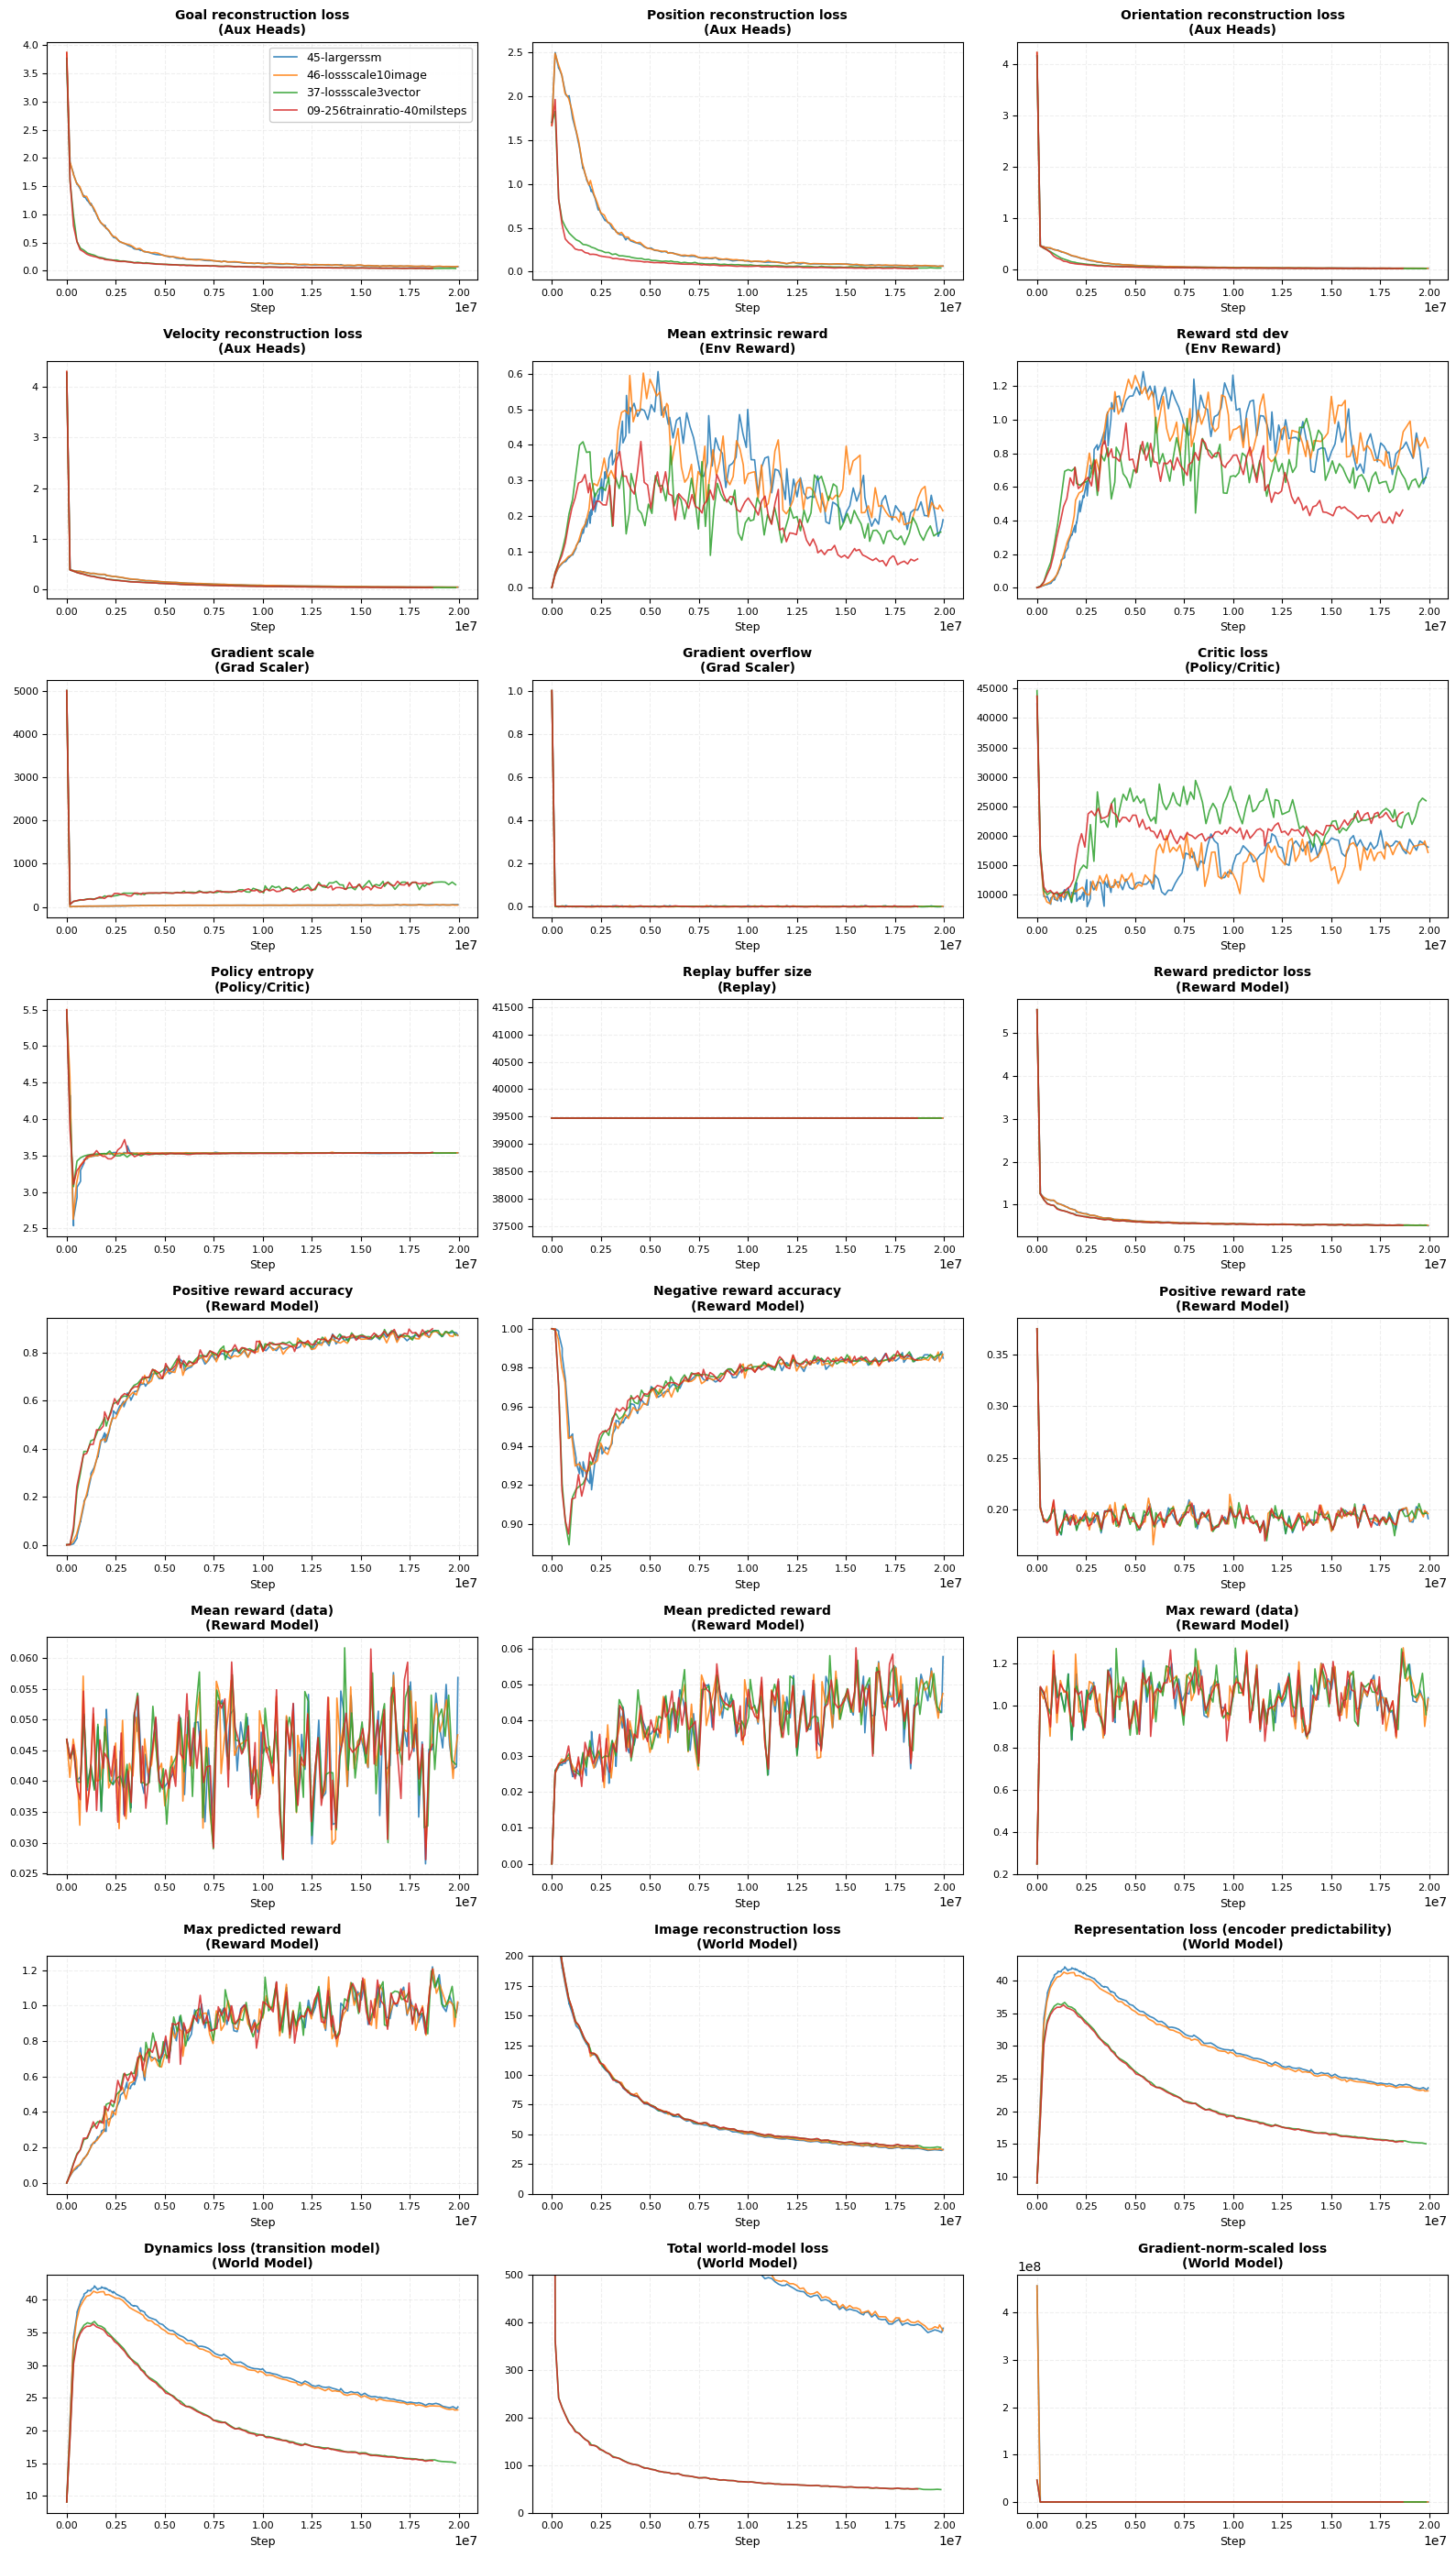


✓ Displayed all 24 metrics from 4 training runs


In [ ]:
# Define all metrics to visualize
metric_info = {
    # ── World model ──────────────────────────────────────────────────────────
    "train/image_loss_mean":      ("World Model",   "Image reconstruction loss"),
    "train/rep_loss_mean":        ("World Model",   "Representation loss (encoder predictability)"),
    "train/dyn_loss_mean":        ("World Model",   "Dynamics loss (transition model)"),
    "train/model_loss_mean":      ("World Model",   "Total world-model loss"),
    "train/model_opt_loss":       ("World Model",   "Gradient-norm-scaled loss"),
    # ── Auxiliary heads ──────────────────────────────────────────────────────
    "train/goal_loss_mean":       ("Aux Heads",     "Goal reconstruction loss"),
    "train/position_loss_mean":   ("Aux Heads",     "Position reconstruction loss"),
    "train/orientation_loss_mean":("Aux Heads",     "Orientation reconstruction loss"),
    "train/velocity_loss_mean":   ("Aux Heads",     "Velocity reconstruction loss"),
    "train/terrain_loss_mean":    ("Aux Heads",     "Terrain reconstruction loss"),
    # ── Reward model ─────────────────────────────────────────────────────────
    "train/reward_loss_mean":     ("Reward Model",  "Reward predictor loss"),
    "train/reward_pos_acc":       ("Reward Model",  "Positive reward accuracy"),
    "train/reward_neg_acc":       ("Reward Model",  "Negative reward accuracy"),
    "train/reward_rate":          ("Reward Model",  "Positive reward rate"),
    "train/reward_avg":           ("Reward Model",  "Mean reward (data)"),
    "train/reward_pred":          ("Reward Model",  "Mean predicted reward"),
    "train/reward_max_data":      ("Reward Model",  "Max reward (data)"),
    "train/reward_max_pred":      ("Reward Model",  "Max predicted reward"),
    # ── Policy & critic ──────────────────────────────────────────────────────
    "train/extr_reward_mean":     ("Env Reward",    "Mean extrinsic reward"),
    "train/extr_reward_std":      ("Env Reward",    "Reward std dev"),
    "train/extr_critic_critic_opt_loss": ("Policy/Critic", "Critic loss"),
    "train/policy_entropy_mag":   ("Policy/Critic", "Policy entropy"),
    # ── Training health ──────────────────────────────────────────────────────
    "train/model_opt_model_opt_grad_scale":    ("Grad Scaler", "Gradient scale"),
    "train/model_opt_model_opt_grad_overflow": ("Grad Scaler", "Gradient overflow"),
    "replay/size":                ("Replay",        "Replay buffer size"),
}

# Load metrics for selected runs
# Uses run_indices_to_plot defined in cell 2 above
# To compare different runs, modify cell 2: run_indices_to_plot = [1, 2, 3, 4]

# Color scheme for multiple runs
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
run_data = {}
run_labels_viz = {}

for i, run_idx in enumerate(run_indices_to_plot):
    if run_idx in all_configs:
        run_path = all_configs[run_idx]['path']
        run_labels_viz[run_idx] = all_configs[run_idx]['label']
        
        metrics_file = run_path / 'metrics.jsonl'
        if metrics_file.exists():
            metrics = []
            with open(metrics_file, 'r') as f:
                for line in f:
                    metrics.append(json.loads(line))
            run_data[run_idx] = pd.DataFrame(metrics)

print(f"✓ Loaded metrics for {len(run_data)} runs")

# Filter metrics that exist in at least one run
available_metrics = [col for col in metric_info.keys() 
                     if any(col in run_data[idx].columns for idx in run_data.keys())]
available_metrics.sort(key=lambda x: metric_info[x][0])

print(f"Visualizing {len(available_metrics)} metrics across {len(set(m[0] for m in metric_info.values()))} groups\n")

# Create grid: 3 columns x n rows
ncols = 3
nrows = (len(available_metrics) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5*nrows))
if nrows == 1 and ncols == 1:
    axes = np.array([axes])  # Handle single subplot case
axes = axes.flatten()

for idx, metric_col in enumerate(available_metrics):
    ax = axes[idx]
    group, short_desc = metric_info[metric_col]
    
    # Plot all selected runs with different colors
    for i, run_idx in enumerate(run_indices_to_plot):
        if run_idx in run_data and metric_col in run_data[run_idx].columns:
            df = run_data[run_idx]
            color = colors[i % len(colors)]
            ax.plot(df['step'], df[metric_col], linewidth=1.2, color=color, 
                   label=run_labels_viz[run_idx], alpha=0.85)
    
    # Format plot
    ax.set_title(f"{short_desc}\n({group})", fontsize=10, fontweight='bold')
    ax.set_xlabel('Step', fontsize=9)
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.tick_params(axis='both', which='major', labelsize=8)
    
    # Set y-axis limits for specific metrics to zoom in on convergence
    if metric_col in ['train/image_loss_mean']:
        ax.set_ylim(0, 200)

    if metric_col in ['train/model_loss_mean']:
        ax.set_ylim(0, 1000)
    
    # Add legend only to first plot
    if idx == 0:
        ax.legend(loc='best', fontsize=9, framealpha=0.95)

# Hide unused subplots
for idx in range(len(available_metrics), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\n✓ Displayed all {len(available_metrics)} metrics from {len(run_indices_to_plot)} training runs")

In [17]:

# Compare final metric values between selected runs
print("\n" + "="*120)
print(f"FINAL METRIC VALUES COMPARISON - {len(run_indices_to_plot)} RUNS")
print("="*120)

# Build header dynamically
header = f"{'Metric':<45}"
for run_idx in run_indices_to_plot:
    header += f"{run_labels[run_idx]:<25}"
print(f"\n{header}")
print("-"*120)

# Build comparison table
for metric_col in sorted(available_metrics):
    group, short_desc = metric_info[metric_col]
    row = f"{short_desc:<45}"
    
    values_list = []
    for run_idx in run_indices_to_plot:
        if run_idx in run_data and metric_col in run_data[run_idx].columns:
            val = run_data[run_idx][metric_col].iloc[-1]
            values_list.append(val)
            row += f"{val:>24.6f}"
        else:
            row += f"{'(missing)':>24}"
    
    # Add comparison marker for 2-run case
    if len(values_list) == 2:
        val_1, val_2 = values_list
        if metric_col in ['train/extr_reward_mean', 'train/reward_pos_acc', 'train/reward_neg_acc']:
            marker = " ↑" if val_2 > val_1 else " ↓"
        else:
            marker = " ✓" if val_2 < val_1 else " ✗"
        row += marker
    
    print(row)

print("="*120)
print("\nMarkers (2-run comparison only):")
print("↑ = Run 2 is better (higher reward, higher accuracy)")
print("↓ = Run 1 is better (higher reward, higher accuracy)")
print("✓ = Run 2 is better (lower loss)")
print("✗ = Run 1 is better (lower loss)")
print("="*120)

print(f"\n📊 TRAINING RUNS SELECTED")
for run_idx in run_indices_to_plot:
    print(f"   • {run_labels[run_idx]}: {len(run_data[run_idx]) if run_idx in run_data else 0} checkpoints")


FINAL METRIC VALUES COMPARISON - 4 RUNS

Metric                                       45-largerssm             46-lossscale10image      37-lossscale3vector      09-256trainratio-40milsteps
------------------------------------------------------------------------------------------------------------------------
Replay buffer size                                       39479.000000            39479.000000            39479.000000            39479.000000
Dynamics loss (transition model)                            23.602055               23.139262               15.052746               15.371101
Critic loss                                              18038.388354            17131.035192            25930.561679            23992.129012
Mean extrinsic reward                                        0.190434                0.215622                0.155785                0.080398
Reward std dev                                               0.710919                0.833043                0.655712    

In [18]:
# All training runs overview - comprehensive metrics
import pandas as pd

print("\n" + "="*200)
print("ALL TRAINING RUNS - COMPREHENSIVE METRICS OVERVIEW")
print("="*200)

all_runs_data = []

# Metrics to extract for each run
metrics_to_track = {
    'train/extr_reward_mean': 'Final Reward',
    'train/model_loss_mean': 'Model Loss',
    'train/image_loss_mean': 'Image Loss',
    'train/rep_loss_mean': 'Rep Loss',
    'train/dyn_loss_mean': 'Dyn Loss',
    'train/reward_loss_mean': 'Reward Loss',
    'train/reward_pos_acc': 'Reward Pos Acc',
    'train/reward_neg_acc': 'Reward Neg Acc',
    'train/velocity_loss_mean': 'Velocity Loss',
    'train/position_loss_mean': 'Position Loss',
    'train/goal_loss_mean': 'Goal Loss',
    'train/terrain_loss_mean': 'Terrain Loss',
    'train/policy_entropy_mag': 'Policy Entropy',
    'train/model_opt_model_opt_grad_scale': 'Grad Scale',
}

for run_idx, run_path in enumerate(available_runs):
    label = run_path.name.split('dreamer-results-')[1][13:]  # Extract label
    
    # Load metrics
    df = load_metrics(run_path)
    
    if df is not None:
        run_data = {'label': label, 'run_idx': run_idx, 'checkpoints': len(df)}
        
        # Extract all metrics (final values)
        for metric_key, metric_name in metrics_to_track.items():
            if metric_key in df.columns:
                run_data[metric_name] = df[metric_key].iloc[-1]
            else:
                run_data[metric_name] = np.nan
        
        all_runs_data.append(run_data)

# Convert to DataFrame for nice display
if all_runs_data:
    df_summary = pd.DataFrame(all_runs_data)
    
    # Display full table
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', None)
    
    # Create display dataframe with selected columns
    display_cols = ['label', 'checkpoints'] + list(metrics_to_track.values())
    df_display = df_summary[display_cols].copy()
    df_display = df_display.round(4)
    
    print("\n" + df_display.to_string(index=False))
    print("\n" + "="*200)
    
    # Top performers rankings
    print("\n🏆 TOP PERFORMERS BY METRIC:\n")
    
    print("  Best Final Reward:")
    top_reward = df_summary.nlargest(3, 'Final Reward')[['label', 'Final Reward']]
    for i, (idx, row) in enumerate(top_reward.iterrows(), 1):
        print(f"    {i}. {row['label']:<50} → {row['Final Reward']:.6f}")
    
    print("\n  Lowest Model Loss:")
    best_loss = df_summary.nsmallest(3, 'Model Loss')[['label', 'Model Loss']]
    for i, (idx, row) in enumerate(best_loss.iterrows(), 1):
        print(f"    {i}. {row['label']:<50} → {row['Model Loss']:.6f}")
    
    print("\n  Best Reward Accuracy (Pos):")
    best_reward_acc = df_summary.nlargest(3, 'Reward Pos Acc')[['label', 'Reward Pos Acc']]
    for i, (idx, row) in enumerate(best_reward_acc.iterrows(), 1):
        print(f"    {i}. {row['label']:<50} → {row['Reward Pos Acc']:.6f}")
    
    print("\n  Lowest Image Loss:")
    best_img_loss = df_summary.nsmallest(3, 'Image Loss')[['label', 'Image Loss']]
    for i, (idx, row) in enumerate(best_img_loss.iterrows(), 1):
        print(f"    {i}. {row['label']:<50} → {row['Image Loss']:.6f}")
    
    print("\n  Lowest Terrain Loss:")
    best_terrain_loss = df_summary.nsmallest(3, 'Terrain Loss')[['label', 'Terrain Loss']]
    for i, (idx, row) in enumerate(best_terrain_loss.iterrows(), 1):
        if not np.isnan(row['Terrain Loss']):
            print(f"    {i}. {row['label']:<50} → {row['Terrain Loss']:.6f}")
else:
    print("No runs to display")



ALL TRAINING RUNS - COMPREHENSIVE METRICS OVERVIEW



                      label  checkpoints  Final Reward  Model Loss  Image Loss  Rep Loss  Dyn Loss  Reward Loss  Reward Pos Acc  Reward Neg Acc  Velocity Loss  Position Loss  Goal Loss  Terrain Loss  Policy Entropy  Grad Scale
            40-non-informed           96        0.1217     89.1497     68.5329   33.1482   33.1482       0.5697          0.8588          0.9406         0.0532         0.0305     0.0589           NaN          2.9502    321.5716
       14-imagelossscale100          142        0.2147   3664.1132     36.4961   26.9638   26.9598       0.5229          0.8892          0.9883         0.0513         0.0682     0.0873           NaN          3.5346      5.0493
           48-256trainratio          117        0.2466    118.6285     93.2008   40.3784   40.3784       0.6578          0.7075          0.9491         0.1231         0.1834     0.1747           NaN          3.6408    314.8452
  54-smallrssm128trainratio           57        0.4061     96.8169     75.2495   34.5938   